## STO-3G Benchmarking

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import glob
import torch
import time
from cace.tasks import LightningTrainingTask
from deeporb.data import OrbDataset, OrbData
from deeporb.ceonet import CEONet
from cace.models import NeuralNetworkPotential
from deeporb.atomwise import AttentionAtomwise
from cace.tasks import GetLoss
from deeporb.metrics import Metrics
import numpy as np
import matplotlib.pyplot as plt
import hashlib
from pathlib import Path
import h5py

/home/king1305/.local/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/home/king1305/.local/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [4]:
from pyscf import gto, scf
def get_small_energies(mol_large,F_large,basis="def2svp"):
    mol_small = gto.Mole()
    mol_small.atom = mol_large.atom
    mol_small.basis = basis
    mol_small.verbose = 0
    mol_small.build()
    
    mf_small = scf.RKS(mol_small)
    mf_small.xc = "b3lyp5"
    mf_small.kernel()

    proj_mo_coeff = scf.addons.project_mo_nr2nr(mol_small,mf_small.mo_coeff,mol_large)
    F_mo = proj_mo_coeff.T @ F_large @ proj_mo_coeff #Okay a lot better
    mo_energy_2 = np.diag(F_mo)
    
    # print("Original energies:",mf_small.mo_energy)
    # print("Projected energies:",mo_energy_2)
    return mol_small, mf_small.mo_coeff, mo_energy_2, mf_small.mo_occ

In [15]:
# import os
# import numpy as np
# from deeporb.data_gen import OrbExtract
# from deeporb.qh9 import QH9data
# from tqdm import tqdm
# import glob
# import h5py

# NUM_MOLECULES = 100
# #Data from the QH9 datasets
# edata = QH9data(root="../../deeporb/datasets")
    
# fn = f"../data/qh9_631gd.h5"
# if os.path.isfile(fn):
#     os.system(f"rm {fn}")

# #Generate orbitals in a smaller basis w/ 
# onum = 0
# for sys_idx in tqdm(range(NUM_MOLECULES)):
#     mol, h, mo_energy, mos, mo_occ = edata.get(sys_idx)
#     mol2, mos2, mo_energy_2, mo_occ_2 = get_small_energies(mol,h,basis="6-31g(d)")
#     # mol2, mos2, mo_energy_2, mo_occ_2 = get_small_energies(mol,h,basis="sto3g")
#     obj = OrbExtract(mol=mol2, mo_ene=mo_energy_2, mo_coeff=mos2, mo_occ=mo_occ_2)
#     mo_idx = np.where((obj.mo_occ == 2)*(obj.mo_ene > -1.75))[0]
#     for i in mo_idx:
#         with h5py.File(fn, "a") as f:
#             for k,v in obj.extract_nlm(i,rotate=False).items():
#                 if isinstance(v,dict):
#                     for k2,v2 in v.items():
#                         f.create_dataset(f"o{onum}/{k}_{k2}", data=v2)
#                 else:
#                     f.create_dataset(f"o{onum}/{k}", data=v)
#             onum += 1

fn = f"../data/qh9_631gd.h5"
from deeporb.default_net import get_model, get_params
params = get_params("qh9","occ")
print("Making dataset...")
data = OrbData(data_path=fn,batch_size=params["BATCH_SIZE"],cutoff=params["CUTOFF"],avge0=params["AVGE0"],sigma=params["SIGMA"]
               ,train_split=0.0,val_split=1.0,test_split=0.0)
data.setup()
print("Done!")

Making dataset...
Done!


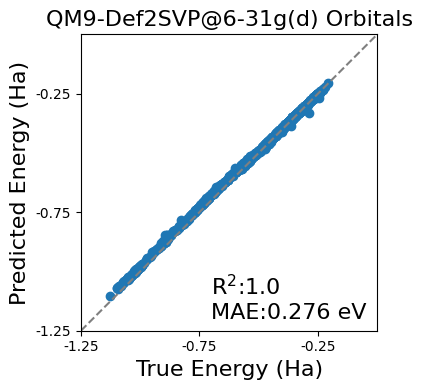

In [19]:
model = get_model("qh9","occ",100000)
model.cuda()
import numpy as np
preds, trues = [], []
for batch in data.val_dataloader():
    batch.cuda()
    out = model(batch,training=False)
    pred = out["pred_energy"]*params["SIGMA"] + params["AVGE0"]
    true = batch["energy"]
    preds.append(pred.detach().cpu().numpy())
    trues.append(true.detach().cpu().numpy())
preds = np.hstack(preds)
trues = np.hstack(trues)
import matplotlib.pyplot as plt

import scipy
import matplotlib.pyplot as plt
plt.figure(figsize=(4,4))
plt.scatter(trues,preds)
hartree_to_ev = 27.2114
occ_mae = np.round(np.abs(preds - trues).mean()*hartree_to_ev,3)
occ_r2 = np.round(scipy.stats.pearsonr(trues,preds)[0]**2,2)
xmin, xmax = -1.25, 0
x = y = np.arange(xmin,xmax+1)
plt.plot(x,y,linestyle="--",color="grey")
plt.xlim(xmin,xmax)
plt.ylim(xmin,xmax)
tcks = np.round(np.arange(xmin,xmax,0.5),2)
plt.xticks(tcks,tcks)
plt.yticks(tcks,tcks)
plt.gca().set_aspect('equal')
# plt.legend()
djvfont = {'fontname':'DejaVu Sans'}
fs=16
plt.ylabel("Predicted Energy (Ha)",fontsize=16,**djvfont)
plt.xlabel("True Energy (Ha)",fontsize=16,**djvfont)
plt.title("QM9-Def2SVP@6-31g(d) Orbitals",fontsize=16,**djvfont)
plt.text(-.7,-1.1,f"R$^2$:{occ_r2}",fontsize=16,**djvfont)
plt.text(-.7,-1.2,f"MAE:{occ_mae} eV",fontsize=16,**djvfont)
plt.tight_layout()
plt.savefig("../figures/631g_def2.png",dpi=500)